# Wearable Health Device Analytics

## Predicting Customer Satisfaction Using Statistical Analysis and Machine Learning

**Author:** Leonard Amoako  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Statsmodels, Matplotlib, Seaborn

## Project Overview

This project analyzes wearable health device performance data to identify the factors that influence customer satisfaction. The analysis evaluates how pricing, battery life, health sensor count, GPS accuracy, and overall device performance contribute to user satisfaction.

The project includes exploratory data analysis, statistical modeling, machine learning, clustering, and model evaluation to generate business insights for product and pricing decisions.

# Data Import

This project begins by importing the Python libraries required for data manipulation, statistical analysis, visualization, and machine learning. The analysis leverages the Pandas ecosystem together with Scikit-learn and Statsmodels to build predictive models and evaluate customer satisfaction drivers.

In [4]:
# Import necessary libraries
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import math
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pylab as py
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree


# Loading the Dataset

The wearable health device performance dataset is loaded into a Pandas DataFrame. The dataset contains technical specifications, sensor performance metrics, battery characteristics, pricing information, and customer satisfaction ratings for multiple wearable devices.

In [5]:
import pandas as pd

# Load wearable health device dataset
df = pd.read_csv("wearable_health_device_performance.csv")

# Display first five observations
df.head()

Mounted at /content/drive


,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score
0,2025-06-01,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4
1,2025-06-01,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1
2,2025-06-01,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3
3,2025-06-01,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0
4,2025-06-01,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2


# Initial Data Exploration

An initial inspection of the dataset is performed to verify successful loading, review variable names, examine data types, and understand the overall structure before data preprocessing.

In [6]:
# Show first 5 rows as verification check
df.head(5)

,Test_Date,Device_Name,Brand,Model,Category,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,Water_Resistance_Rating,User_Satisfaction_Rating,GPS_Accuracy_Meters,Connectivity_Features,Health_Sensors_Count,App_Ecosystem_Support,Performance_Score
0,2025-06-01,Fitbit Inspire 4,Fitbit,Inspire 4,Fitness Tracker,141.74,129.9,89.69,93.03,78.91,3ATM,6.5,NaN,"Bluetooth, WiFi",5,Cross-platform,68.4
1,2025-06-01,Apple Watch SE 3,Apple,Watch SE 3,Smartwatch,834.64,26.5,95.92,98.20,79.76,IP68,8.3,4.9,"WiFi, Bluetooth, NFC",8,iOS,60.1
2,2025-06-01,Fitbit Versa 4,Fitbit,Versa 4,Sports Watch,145.34,161.2,92.24,96.81,74.49,IPX8,6.0,1.7,Bluetooth,7,Cross-platform,59.3
3,2025-06-01,Polar Vantage V3,Polar,Vantage V3,Smartwatch,349.53,69.4,96.77,95.56,78.06,IP68,8.0,3.2,"WiFi, Bluetooth, NFC, LTE",12,Cross-platform,61.0
4,2025-06-01,Samsung Galaxy Watch FE,Samsung,Galaxy Watch FE,Smartwatch,502.43,39.7,92.27,98.15,75.23,IPX8,8.3,1.6,"WiFi, Bluetooth, NFC, LTE",14,Android/iOS,61.2


# Data Preprocessing

The raw dataset is prepared for predictive modeling by creating a working copy, encoding categorical variables, removing non-predictive attributes, and handling missing observations. These preprocessing steps improve model quality and reduce unnecessary complexity.

# Feature Engineering

Categorical variables are transformed into numerical representations using one-hot encoding. Features that do not contribute to predictive performance, such as identifiers and descriptive text fields, are removed to create a modeling-ready dataset.

In [7]:
dat_wearable = df.copy()

# Dummy Code Category column

dat_wearable = pd.get_dummies(dat_wearable, columns=['Category'], drop_first=True)

# Drop Columns with unneccesary data we will not be using
dat_wearable.drop('Test_Date', axis=1, inplace=True)
dat_wearable.drop('Device_Name', axis=1, inplace=True)
dat_wearable.drop('Brand', axis=1, inplace=True)
dat_wearable.drop('Model', axis=1, inplace=True)
dat_wearable.drop('Water_Resistance_Rating', axis=1, inplace=True)
dat_wearable.drop('Connectivity_Features', axis=1, inplace=True)
dat_wearable.drop('App_Ecosystem_Support', axis=1, inplace=True)
dat_wearable.drop('Category_Fitness Tracker', axis=1, inplace=True)
dat_wearable.drop('Category_Smart Ring', axis=1, inplace=True)
dat_wearable.drop('Category_Smartwatch', axis=1, inplace=True)
dat_wearable.drop('Category_Sports Watch', axis=1, inplace=True)

# Drop columns with missing data
dat_wearable = dat_wearable.dropna()

In [8]:
dat_wearable.head(5)

,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,User_Satisfaction_Rating,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
1,834.64,26.5,95.92,98.20,79.76,8.3,4.9,8,60.1
2,145.34,161.2,92.24,96.81,74.49,6.0,1.7,7,59.3
3,349.53,69.4,96.77,95.56,78.06,8.0,3.2,12,61.0
4,502.43,39.7,92.27,98.15,75.23,8.3,1.6,14,61.2
5,402.32,287.4,92.85,99.34,77.58,8.1,2.3,11,63.6


In [9]:
# Calculate mean of User Satisfaction
# We can use this measure later to compare clusters of predictor data
print(dat_wearable['User_Satisfaction_Rating'].mean())

8.102696500286863


In [10]:
# Separate Predictor Values, X, from Target Value, Y
y = dat_wearable['User_Satisfaction_Rating']
x = dat_wearable.drop(['User_Satisfaction_Rating'], axis=1)

In [11]:
# Check columns of x & y
y.head(5)


,User_Satisfaction_Rating
1,8.3
2,6.0
3,8.0
4,8.3
5,8.1


In [12]:
x.head(5)

,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
1,834.64,26.5,95.92,98.20,79.76,4.9,8,60.1
2,145.34,161.2,92.24,96.81,74.49,1.7,7,59.3
3,349.53,69.4,96.77,95.56,78.06,3.2,12,61.0
4,502.43,39.7,92.27,98.15,75.23,1.6,14,61.2
5,402.32,287.4,92.85,99.34,77.58,2.3,11,63.6


## Exploratory Scatter Plots
Preliminary visuals

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to identify relationships between device characteristics and customer satisfaction. Scatter plots and descriptive statistics help reveal trends, correlations, and potential predictors prior to model development.

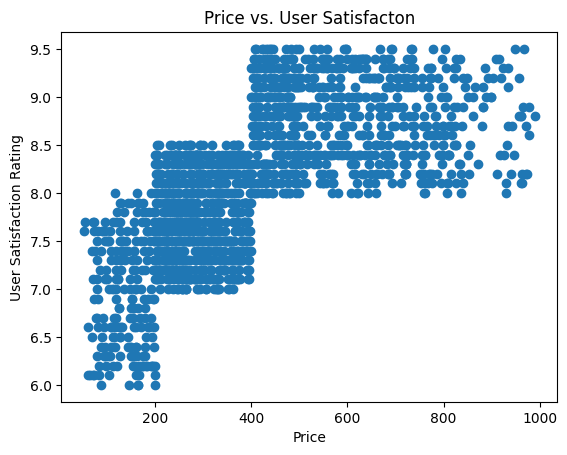

In [13]:
# Show scatter plot of user satisfaction ratings @ a Price

plt.scatter(dat_wearable.loc[:,'Price_USD'], dat_wearable.loc[:,'User_Satisfaction_Rating'])

# Add labels and title
plt.xlabel("Price")
plt.ylabel("User Satisfaction Rating")
plt.title("Price vs. User Satisfacton")

# Show the plot
plt.show()

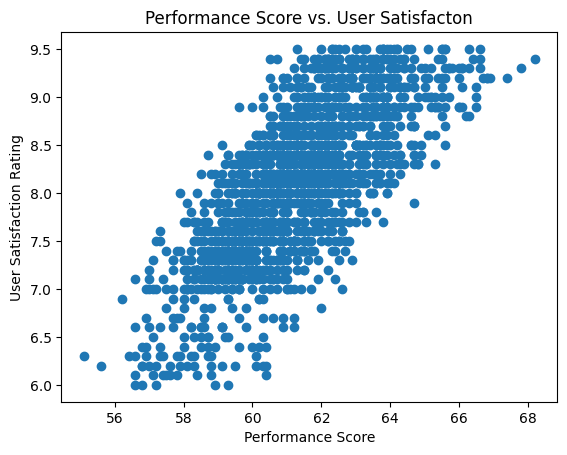

In [14]:
plt.scatter(dat_wearable.loc[:,'Performance_Score'], dat_wearable.loc[:,'User_Satisfaction_Rating'])

# Add labels and title
plt.xlabel("Performance Score")
plt.ylabel("User Satisfaction Rating")
plt.title("Performance Score vs. User Satisfacton")

# Show the plot
plt.show()

# Correlation Analysis

A correlation matrix is generated to quantify the strength and direction of relationships among numerical variables. This analysis helps identify highly influential predictors and detect potential multicollinearity before model fitting.

In [15]:
# Correlation matrix
cor = dat_wearable.corr()
cor


,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,User_Satisfaction_Rating,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
Price_USD,1.000000,0.240355,-0.008767,0.419832,0.083514,0.689094,-0.019312,0.116392,0.593070
Battery_Life_Hours,0.240355,1.000000,-0.021367,0.427608,-0.177284,0.115698,0.005251,-0.228849,0.433363
Heart_Rate_Accuracy_Percent,-0.008767,-0.021367,1.000000,-0.020773,0.000040,0.006515,0.016022,0.021022,0.132352
Step_Count_Accuracy_Percent,0.419832,0.427608,-0.020773,1.000000,0.080925,0.260107,-0.012208,0.058790,0.470645
Sleep_Tracking_Accuracy_Percent,0.083514,-0.177284,0.000040,0.080925,1.000000,0.117289,-0.015465,0.389646,0.158048
User_Satisfaction_Rating,0.689094,0.115698,0.006515,0.260107,0.117289,1.000000,-0.030588,0.126629,0.736987
GPS_Accuracy_Meters,-0.019312,0.005251,0.016022,-0.012208,-0.015465,-0.030588,1.000000,-0.006962,-0.361219
Health_Sensors_Count,0.116392,-0.228849,0.021022,0.058790,0.389646,0.126629,-0.006962,1.000000,-0.051570
Performance_Score,0.593070,0.433363,0.132352,0.470645,0.158048,0.736987,-0.361219,-0.051570,1.000000


In [16]:
cor['User_Satisfaction_Rating'].sort_values(ascending=False)

,User_Satisfaction_Rating
User_Satisfaction_Rating,1.000000
Performance_Score,0.736987
Price_USD,0.689094
Step_Count_Accuracy_Percent,0.260107
Health_Sensors_Count,0.126629
Sleep_Tracking_Accuracy_Percent,0.117289
Battery_Life_Hours,0.115698
Heart_Rate_Accuracy_Percent,0.006515
GPS_Accuracy_Meters,-0.030588


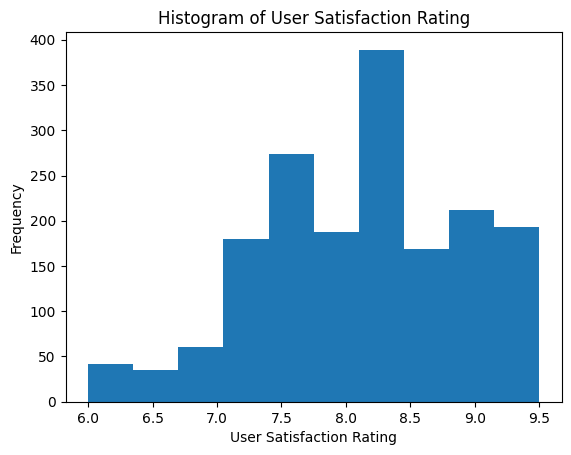

In [17]:
# Histogram
plt.hist(dat_wearable['User_Satisfaction_Rating'], bins=10)
plt.xlabel("User Satisfaction Rating")
plt.ylabel("Frequency")
plt.title("Histogram of User Satisfaction Rating")
plt.show()

Most users seem to give satisfaction ratings in the mid-to-high (~8.0 to 9.0) range, with less users giving ratings as low as 6.0

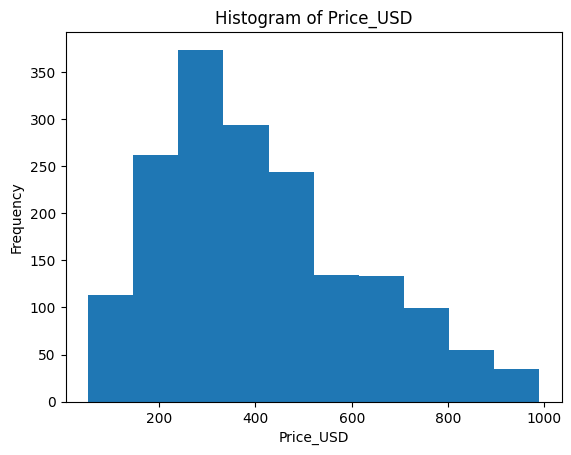

In [18]:
plt.hist(dat_wearable['Price_USD'], bins=10)
plt.xlabel("Price_USD")
plt.ylabel("Frequency")
plt.title("Histogram of Price_USD")
plt.show()

The average price range for wearable health devices seems to be around \$200 to \$600 and extends up almost to $1000.

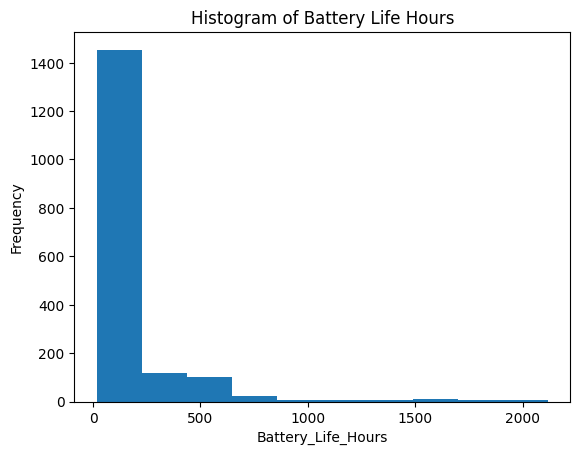

In [19]:
plt.hist(dat_wearable['Battery_Life_Hours'], bins=10)
plt.xlabel("Battery_Life_Hours")
plt.ylabel("Frequency")
plt.title("Histogram of Battery Life Hours")
plt.show()

Battery life of most wearable health devices are under 200 hours. The distribution is very strongly right-skewed with longer battery life being very rare.

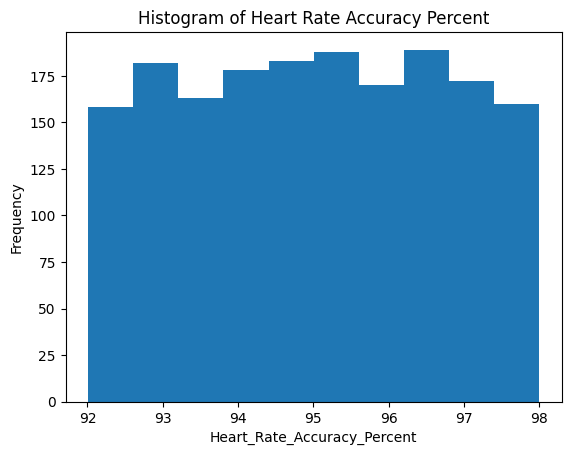

In [20]:
plt.hist(dat_wearable['Heart_Rate_Accuracy_Percent'], bins=10)
plt.xlabel("Heart_Rate_Accuracy_Percent")
plt.ylabel("Frequency")
plt.title("Histogram of Heart Rate Accuracy Percent")
plt.show()

All health devices detect heart rate fairly well with accuracy raning from 92% to 98%

In [21]:
#dat_wearable = dat_wearable[features]
print(dat_wearable.describe())
dat_wearable.head()

         Price_USD  Battery_Life_Hours  Heart_Rate_Accuracy_Percent  \
count  1743.000000         1743.000000                  1743.000000   
mean    410.069443          160.722490                    95.014796   
std     205.162554          273.498534                     1.692516   
min      52.270000           18.000000                    92.010000   
25%     252.660000           39.200000                    93.550000   
50%     373.450000           60.100000                    95.030000   
75%     536.170000          159.950000                    96.455000   
max     989.480000         2118.100000                    98.000000   

       Step_Count_Accuracy_Percent  Sleep_Tracking_Accuracy_Percent  \
count                  1743.000000                      1743.000000   
mean                     96.249512                        78.427355   
std                       1.704311                         3.665931   
min                      93.000000                        70.010000   
25%  

,Price_USD,Battery_Life_Hours,Heart_Rate_Accuracy_Percent,Step_Count_Accuracy_Percent,Sleep_Tracking_Accuracy_Percent,User_Satisfaction_Rating,GPS_Accuracy_Meters,Health_Sensors_Count,Performance_Score
1,834.64,26.5,95.92,98.20,79.76,8.3,4.9,8,60.1
2,145.34,161.2,92.24,96.81,74.49,6.0,1.7,7,59.3
3,349.53,69.4,96.77,95.56,78.06,8.0,3.2,12,61.0
4,502.43,39.7,92.27,98.15,75.23,8.3,1.6,14,61.2
5,402.32,287.4,92.85,99.34,77.58,8.1,2.3,11,63.6


# Multiple Linear Regression

A Multiple Linear Regression model is developed to quantify the relationship between wearable device characteristics and customer satisfaction ratings. The model estimates the influence of pricing, battery life, sensor accuracy, GPS accuracy, health sensor count, and overall performance while controlling for the remaining variables.

The statistical significance of each predictor is evaluated using hypothesis testing, coefficient estimates, and overall model fit statistics.

In [22]:
# Regression Model
model = smf.ols(formula='User_Satisfaction_Rating~Price_USD+Battery_Life_Hours+Heart_Rate_Accuracy_Percent+Step_Count_Accuracy_Percent+Sleep_Tracking_Accuracy_Percent+GPS_Accuracy_Meters+Health_Sensors_Count+Performance_Score', data=df)
result = model.fit()

# Regression Results

The regression output provides coefficient estimates, significance levels, confidence intervals, and model diagnostics. The results are interpreted to identify which wearable device characteristics significantly influence customer satisfaction.

In [23]:
# Print OLS Regression Results
print(result.summary())

                               OLS Regression Results                               
Dep. Variable:     User_Satisfaction_Rating   R-squared:                       0.794
Model:                                  OLS   Adj. R-squared:                  0.793
Method:                       Least Squares   F-statistic:                     835.1
Date:                      Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                              01:14:15   Log-Likelihood:                -673.41
No. Observations:                      1743   AIC:                             1365.
Df Residuals:                          1734   BIC:                             1414.
Df Model:                                 8                                         
Covariance Type:                  nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

R2 of .794 is very high. Adjusted R Squared nearly identical, meaning model is a good fit.

Low P Values shows that the variables are all highly statistically significant. (F Stat of 835 shows model is overall highly statistically significant)

H₀ (null): There is no significant relationship between Price_USD and User_Satisfaction_Rating.
H₁ (alt): There is a significant relationship between Price_USD and User_Satisfaction_Rating.

Since The p-value < 0.05, so you rejected the null hypothesis.

High T-Stats such as Performance Score (51.2) indicate high correlation between these variables and User Satisfaction. Other predictors such as Health Sensor Count and GPS Accuracy also correlate with User Satisfaction. (So does Price!)

Lower Accuracy for Step Counts and Heart Rates impacts User Satisfaction negatively.

Performance Score Coef. of .37 suggests a strong positive relationship with User Satisfaction.

# Multicollinearity Assessment

Variance Inflation Factor (VIF) is computed to assess multicollinearity among the predictor variables. High VIF values indicate that some explanatory variables are highly correlated, which may inflate coefficient estimates and reduce model stability.

In [24]:
#Variance Inflation Factor
vif_data=pd.DataFrame()
vif_data["feature"]=x.columns

# Convert boolean columns to numeric (0s and 1s)
x_numeric = x.copy()
for col in ['Category_Fitness Tracker', 'Category_Smart Ring', 'Category_Smartwatch', 'Category_Sports Watch']:
    if col in x_numeric.columns:
        x_numeric[col] = x_numeric[col].astype(int)

vif_data["VIF"]=[variance_inflation_factor(x_numeric.values,i) for i in range(x_numeric.shape[1])]
print(vif_data)

                           feature          VIF
0                        Price_USD     8.312255
1               Battery_Life_Hours     1.938790
2      Heart_Rate_Accuracy_Percent  2298.484213
3      Step_Count_Accuracy_Percent  2724.239381
4  Sleep_Tracking_Accuracy_Percent   601.445274
5              GPS_Accuracy_Meters    14.749597
6             Health_Sensors_Count    19.255940
7                Performance_Score  2701.455036


SPLIT DATA INTO TRAINING & TESTING

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.35, random_state=42)

# Compare means of the training and testing partition
print(y_train.mean())
print(y_test.mean())

8.105565371024735
8.097381342062192


In [26]:
# Build the MultiLinearRegression model
lr = LinearRegression()
lr.fit(x_train, y_train)



LinearRegression()

In [27]:
# Predict on test data
y_test_pred = lr.predict(x_test)


In [28]:
# R2 and RMSE for Training Data
y_train_pred = lr.predict(x_train)
r_squared_train = r2_score(y_train, y_train_pred)
print("R-squared:", r_squared_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE:", rmse_train)

R-squared: 0.8003392919329285
RMSE: 0.35658666846739695


In [29]:
# R2 and RMSE fo Testing Data
r_squared = r2_score(y_test, y_test_pred)
print("R-squared:", r_squared)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)

R-squared: 0.7799586420189542
RMSE: 0.355838880045417


R2 of .83 means 83% of of the variance in User Satisfaction is explained by the model. RMSE indicates predictions are within .31 points of the actual User Satisfaction (the model is accurate).

In [30]:
# Find Mean of Price
print(dat_wearable['Price_USD'].mean())

410.0694434882387


The P Value is 0, less than .05. This means that price has a significant effect on User Satisfaction. The null hypothesis can be rejected.

 K-Nearest-Neighbor Regression




# K-Nearest Neighbors Regression

K-Nearest Neighbors (KNN) regression is implemented to capture nonlinear relationships between wearable device characteristics and customer satisfaction. Unlike linear regression, KNN predicts outcomes based on the similarity of neighboring observations.

In [31]:
#KNN with training data
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsRegressor()

In [32]:
y_pred = knn.predict(x_train)


In [39]:
#KNN with test data
knn.fit(x_test, y_test)

KNeighborsRegressor()

In [34]:
y_pred = knn.predict(x_test)

print('RMSE: ',sqrt(mean_squared_error(y_test, y_pred)))

RMSE:  0.4013341090701234


Decision-Tree Regression

In [35]:
regtree = DecisionTreeRegressor(max_depth=3)
regtree.fit(x, y)

y_pred = regtree.predict(x)

In [36]:
y_pred = regtree.predict(x_test)
print('RMSE: ',sqrt(mean_squared_error(y_test, y_pred)))

RMSE:  0.3913848843439746


Clustering 2

In [37]:
# Using scikit-learn to perform K-Means clustering
# Specify the number of clusters (2) and fit the data
kmeans = KMeans(n_clusters=2, random_state=42).fit(dat_wearable)

print(dat_wearable.columns)
print(kmeans.cluster_centers_)
labels = (kmeans.labels_)
counts = np.bincount(labels[labels>=0])
print(counts)

Index(['Price_USD', 'Battery_Life_Hours', 'Heart_Rate_Accuracy_Percent',
       'Step_Count_Accuracy_Percent', 'Sleep_Tracking_Accuracy_Percent',
       'User_Satisfaction_Rating', 'GPS_Accuracy_Meters',
       'Health_Sensors_Count', 'Performance_Score'],
      dtype='object')
[[386.21121347  89.32344346  95.02730623  95.98162643  78.51915502
    8.05749682   3.24752224  10.45044473  61.01423126]
 [632.27568047 825.70532544  94.89828402  98.74449704  77.57236686
    8.52366864   3.24911243   9.5739645   63.9112426 ]]
[1574  169]


Clustering 3

In [38]:
# Using scikit-learn to perform K-Means clustering
# Specify the number of clusters (3) and fit the data
kmeans = KMeans(n_clusters=3, random_state=42).fit(dat_wearable)

print(dat_wearable.columns)
print(kmeans.cluster_centers_)
labels = (kmeans.labels_)
counts = np.bincount(labels[labels>=0])
print(counts)

Index(['Price_USD', 'Battery_Life_Hours', 'Heart_Rate_Accuracy_Percent',
       'Step_Count_Accuracy_Percent', 'Sleep_Tracking_Accuracy_Percent',
       'User_Satisfaction_Rating', 'GPS_Accuracy_Meters',
       'Health_Sensors_Count', 'Performance_Score'],
      dtype='object')
[[ 291.72467298  100.07168675   95.06828744   95.77049914   78.29019793
     7.7848537     3.25327022   10.18330465   60.5863167 ]
 [ 606.43148936 1497.70851064   94.92489362   98.72361702   77.27808511
     8.62340426    3.21702128    8.4893617    64.05319149]
 [ 650.30840824  175.02565543   94.90631086   97.07410112   78.82696629
     8.74850187    3.23820225   10.92696629   62.59475655]]
[1163   47  533]


# Business Insights

The analysis demonstrates that several technical and pricing-related factors significantly influence customer satisfaction with wearable health devices.

Key findings include:

- Devices with higher overall performance scores receive higher customer satisfaction ratings.
- GPS accuracy and health sensor quality contribute positively to customer experience.
- Battery life remains an important purchasing consideration.
- Pricing has a significant relationship with customer satisfaction, suggesting consumers associate price with perceived quality.
- Machine learning models successfully captured complex relationships within the data, providing additional predictive capability beyond traditional statistical methods.

These insights can support manufacturers in product development, pricing strategies, and feature prioritization.

# Conclusion

This project demonstrates an end-to-end data analytics workflow using Python for statistical analysis and machine learning.

The project incorporates data preprocessing, exploratory data analysis, correlation analysis, multiple linear regression, regression diagnostics, K-Nearest Neighbors, Decision Tree regression, and K-Means clustering to investigate the factors influencing customer satisfaction with wearable health devices.

Overall, the analysis highlights the value of combining statistical inference with machine learning techniques to generate actionable business insights and improve decision-making in consumer technology markets.